# 04. UMAP + HDBSCAN

03에서 HAC 기반 클러스터링의 한계를 확인했습니다:
- PCA(선형 차원축소)로는 비선형 구조를 보존할 수 없음
- Average + Cosine이 가장 양호했으나, 엘보우가 없어 최적 k를 판단할 수 없음

이를 해결하기 위해:
- **UMAP**: 비선형 차원축소로 고차원 임베딩의 구조를 저차원에 보존
- **HDBSCAN**: 밀도 기반으로 클러스터 수를 자동 결정, 노이즈를 별도 처리

| 단계 | 내용 |
|------|------|
| 1 | UMAP 차원축소 | 
| 2 | HDBSCAN 그리드 서치 | 
| 3 | UMAP 파라미터 변경 실험 |
| 4 | Soft assignment + threshold | 
| 5 | 최종 조합 선택 | 

## 데이터 로드 + 임베딩 확인

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize

df = pd.read_pickle('my_dataframe2.pkl')
X = np.vstack(df['vector'].values)

# L2 정규화 확인
norms = np.linalg.norm(X, axis=1)
print(f'shape: {X.shape}')
print(f'norms - min: {norms.min():.4f}, mean: {norms.mean():.4f}, max: {norms.max():.4f}')
print(f'NaN: {np.isnan(X).any()}, Inf: {np.isinf(X).any()}')

## 1. UMAP 차원축소

768D → 15D로 비선형 차원축소합니다.

- `metric='cosine'`: Ko-SBERT 임베딩과 일관된 거리 함수
- `n_neighbors=50`: 국소/전역 구조의 균형 (30~100 중간값)
- `min_dist=0.0`: 군집을 최대한 조밀하게 → HDBSCAN이 밀도 차이를 쉽게 감지


In [ ]:
import umap

X = normalize(X, copy=False)

umap_dim = 15
um = umap.UMAP(
    n_components=umap_dim,
    metric='cosine',
    n_neighbors=50,
    min_dist=0.0,
    random_state=42,
    verbose=True
)

Z = um.fit_transform(X)      # (n, 15)
Z = normalize(Z, copy=False)
print(f'UMAP 결과: {Z.shape}')

## 2. HDBSCAN 그리드 서치

**1차 목표**: 03에서의 실험값보단 실루엣이 높고 군집수(k)가 해석 가능한 수준(4~6개)인 조합 찾기

평가 지표:
- **실루엣**: 클러스터 분리도
- **노이즈 비율**: -1로 분류된 샘플 비율
- **군집수(k)**: 해석 가능한 수준이어야 함
- **max_share**: 가장 큰 클러스터의 비중 (너무 크면 쏠림)


In [ ]:
import hdbscan
from sklearn.metrics import silhouette_score

def run_hdbscan_and_eval(Z, mcs, ms):
    clus = hdbscan.HDBSCAN(min_cluster_size=mcs,
                           min_samples=ms,
                           metric='euclidean')
    labels = clus.fit_predict(Z)
    mask = labels != -1
    if mask.sum() < 2 or np.unique(labels[mask]).size < 2:
        sil = np.nan
        n_cls = 0
        noise_ratio = 1.0
        max_share = np.nan
    else:
        sil = silhouette_score(Z[mask], labels[mask], metric='euclidean')
        n_cls = np.unique(labels[mask]).size
        counts = np.bincount(labels[mask])
        max_share = counts.max() / mask.sum()
        noise_ratio = 1 - mask.mean()
    return sil, noise_ratio, n_cls, max_share, labels, clus.probabilities_

In [ ]:
import pandas as pd

# 1차: 넓은 범위 탐색
grid = []
for mcs in [800, 1000, 1200, 1500]:
    for ms in [5, 10, None]:  # None = auto
        sil, noise, k, mx, labels, probs = run_hdbscan_and_eval(Z, mcs, ms)
        grid.append({'mcs': mcs, 'ms': ('auto' if ms is None else ms),
                     'k': k, 'sil': sil, 'noise': noise, 'max_share': mx})

df_res = pd.DataFrame(grid).sort_values(['k', 'sil', 'noise'],
                                         ascending=[True, False, True])
print(df_res.to_string(index=False))

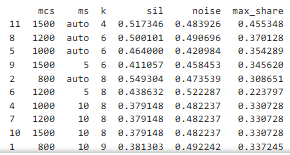

**1차 그리드 서치 결과**: 실루엣 0.27~ 0.52 수준으로 HAC 대비 개선. 그러나 노이즈가 40~ 50%로 매우 높음.

In [ ]:
# 2차: 노이즈를 줄이기 위해 mcs 범위를 높여서 실험
grid = []
for mcs in [1400, 1600, 1800, 2000]:
    for ms in [3, 5, 7]:
        sil, noise, k, mx, labels, probs = run_hdbscan_and_eval(Z, mcs, ms)
        grid.append({'mcs': mcs, 'ms': ms, 'k': k, 'sil': sil, 'noise': noise,
                     'max_share': mx, 'labels': labels})

df_res = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in grid])
print(df_res.to_string(index=False))

**2차 그리드 서치 결과**: 노이즈 줄이려고 mcs를 1400~2000으로 올려봄 → 결과가 전부 동일, mcs 올리는 건 의미 없음

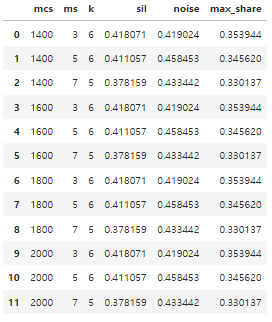

## 3. UMAP 파라미터 변경 실험

노이즈가 높은 편이여, UMAP 파라미터를 변경하면 개선될 수 있을지 실험합니다.

- `n_neighbors`: 50 → 170 (전역 구조 강조)
- `min_dist`: 0.0 → 0.2 (군집을 넓게 퍼뜨려 노이즈 감소 기대)


In [ ]:
# UMAP 파라미터 변경 실험 (n_neighbors=170, min_dist=0.2)
import hdbscan
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import numpy as np

um2 = umap.UMAP(
    n_components=15,
    metric='cosine',
    n_neighbors=170,      # 50 → 170
    min_dist=0.2,         # 0.0 → 0.2
    random_state=42,
    verbose=True
)

Z2 = um2.fit_transform(X)
Z2 = normalize(Z2, copy=False)

# 동일 조합으로 비교
cands = [(1000, 3), (1000, 5), (1200, 3), (1200, 5), (1500, 3), (1500, 5)]

for mcs, ms in cands:
    sil, nz, k, mx, labels, probs = run_hdbscan_and_eval(Z2, mcs, ms, metric='euclidean')
    print(f"[mcs={mcs}, ms={ms}] silhouette={sil:.4f}, noise={nz:.2%}, k={k}, max_share={mx:.3f}")

| mcs | ms | silhouette | noise | k | max_share |
|-----|-----|-----------|-------|---|-----------|
| 1000 | 3 | 0.4195 | 59.83% | 9 | 0.202 |
| 1000 | 5 | 0.4004 | 58.81% | 8 | 0.218 |
| 1200 | 3 | 0.4212 | 57.34% | 7 | 0.212 |
| 1200 | 5 | 0.4004 | 58.81% | 8 | 0.218 |
| 1500 | 3 | 0.4212 | 57.34% | 7 | 0.212 |
| 1500 | 5 | 0.4372 | 61.11% | 7 | 0.231 |

1차(nn=50, min_dist=0.0)에서 노이즈 40~ 50%였으나, 파라미터 변경(nn=170, min_dist=0.2) 후 노이즈가 57~61%로 오히려 악화. UMAP 파라미터 조정만으로는 노이즈를 줄일 수 없다고 판단 → 원래 설정 유지.

## 4. Soft Assignment + Threshold

UMAP 설정은 유지하고, HDBSCAN의 노이즈(-1)를 사후 처리로 줄이는 방법을 시도합니다.

**방법**: HDBSCAN의 soft assignment로 노이즈 샘플에 대해 "가장 가능성 높은 군집"과 확률(strength)을 계산. threshold 이상인 경우만 해당 군집에 편입.


In [ ]:
from hdbscan import approximate_predict

# --- HDBSCAN 학습 + base 결과 ---
def fit_hdbscan_base(Z, mcs, ms=None, metric='euclidean'):
    model = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric=metric,
        prediction_data=True
    )
    base_labels = model.fit_predict(Z)
    mask = base_labels != -1
    if mask.sum() < 2 or np.unique(base_labels[mask]).size < 2:
        base = {'mcs': mcs, 'ms': ms if ms is not None else 'auto',
                'k': 0, 'sil': np.nan, 'noise': 1.0, 'max_share': np.nan, 'labels': base_labels}
    else:
        sil = silhouette_score(Z[mask], base_labels[mask], metric=metric)
        counts = np.bincount(base_labels[mask])
        base = {'mcs': mcs, 'ms': ms if ms is not None else 'auto',
                'k': int(np.unique(base_labels[mask]).size), 'sil': float(sil),
                'noise': float(1 - mask.mean()), 'max_share': float(counts.max() / mask.sum()),
                'labels': base_labels}
    return model, base

# --- 노이즈에만 soft assignment 적용 ---
def apply_threshold_to_noise_only(model, Z, base_labels, threshold, metric='euclidean'):
    pred_labels, strengths = approximate_predict(model, Z)
    new_labels = base_labels.copy()
    noise_idx = (base_labels == -1)
    accept = (strengths >= threshold)
    to_assign = noise_idx & accept
    new_labels[to_assign] = pred_labels[to_assign]

    mask = new_labels != -1
    if mask.sum() < 2 or np.unique(new_labels[mask]).size < 2:
        return {'k': 0, 'sil': np.nan, 'noise': 1.0, 'max_share': np.nan, 'labels': new_labels}
    sil = silhouette_score(Z[mask], new_labels[mask], metric=metric)
    counts = np.bincount(new_labels[mask])
    return {'k': int(np.unique(new_labels[mask]).size), 'sil': float(sil),
            'noise': float(1 - mask.mean()), 'max_share': float(counts.max() / mask.sum()),
            'labels': new_labels}

In [ ]:
# mcs별 base + threshold 비교
mcs_list = [1400, 1500, 1700]
rows = []

for mcs in mcs_list:
    model, base = fit_hdbscan_base(Z, mcs, ms=None, metric='euclidean')
    rows.append({'mcs': mcs, 'type': 'base', 'k': base['k'],
                 'sil': base['sil'], 'noise': base['noise'], 'max_share': base['max_share']})
    for thr in [0.8, 0.7, 0.6, 0.5, 0.4, 0.3]:
        res = apply_threshold_to_noise_only(model, Z, base['labels'], thr, metric='euclidean')
        rows.append({'mcs': mcs, 'type': f'thr_{thr}', 'k': res['k'],
                     'sil': res['sil'], 'noise': res['noise'], 'max_share': res['max_share']})

df_out = pd.DataFrame(rows)
print(df_out.to_string(index=False))

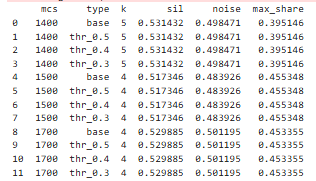

In [ ]:
# 노이즈 샘플의 strength 분포 확인
model, base = fit_hdbscan_base(Z, mcs=1500, ms=None, metric='euclidean')
pred_labels, strengths = approximate_predict(model, Z)

noise_idx = (base['labels'] == -1)
print(f"노이즈 개수: {noise_idx.sum()}")
print(f"노이즈 strengths min/max: {strengths[noise_idx].min()} {strengths[noise_idx].max()}")
print(f"노이즈 strengths quantiles: {np.quantile(strengths[noise_idx], [0.1, 0.25, 0.5, 0.75, 0.9])}")

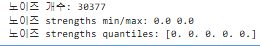

**Soft assignment 결과**: threshold를 0.8에서 0.3까지 낮춰도 base와 결과가 완전히 동일. 원인을 확인해보니 노이즈 샘플(30,377개)의 strength가 전부 0.0으로, 어떤 클러스터와도 유사성이 없다고 판단됨. 즉 노이즈는 경계에 있는 애매한 샘플이 아니라, 진짜 어디에도 속하지 않는 샘플. → **노이즈를 억지로 줄이는 것이 아니라, 노이즈가 가장 낮은 파라미터 조합을 선택하는 방향으로 전환.**

## 5. 최종 조합 선택

2차 그리드 서치와 soft assignment 실험을 거쳐, 노이즈가 가장 낮은 파라미터 조합을 선택합니다.

최종 후보 비교:

| mcs | ms | 군집수 | 실루엣 | 노이즈 | max할당 |
|-----|------|--------|--------|--------|--------|
| 1400 | 7 | 5 | 0.3782 | 0.3782 | 0.3301 |
| 1400 | auto | 5 | 0.5314 | 0.4985 | 0.3951 |
| 1500 | auto | 4 | 0.5173 | 0.4839 | 0.4553 |
| 1700 | auto | 4 | 0.5299 | 0.5012 | 0.4534 |

**선택: mcs=1400, ms=7**

- 실루엣(0.3782)은 다른 후보보다 낮지만, **노이즈가 0.3782로 가장 낮음**
- max할당(0.3301)도 가장 균형적 — 특정 클러스터에 쏠리지 않음
- 다음 단계(LDA 토픽 모델링)에서 노이즈가 적어야 안정적인 토픽 추출이 가능
- 실루엣이 약간 낮더라도 **더 많은 데이터를 활용할 수 있는 쪽이 LDA에 유리**

In [ ]:
# 최종 선택 조합으로 라벨 생성 및 저장
sil, noise, k, mx, labels, probs = run_hdbscan_and_eval(Z, mcs=1400, ms=7)
print(f'mcs=1400, ms=7 -> sil={sil:.4f}, noise={noise:.2%}, k={k}, max_share={mx:.4f}')

df_labels = df.copy()
df_labels['cluster_1400_7'] = labels
df_labels.to_pickle('df_labels.pkl')
print(f'저장 완료: df_labels.pkl')

## 결론

1. **UMAP**: 768D → 15D 비선형 차원축소로 PCA(03 실험 2)의 한계를 극복
2. **HDBSCAN**: 밀도 기반으로 k를 자동 결정하여 엘보우 문제(03 실험 4) 해결
3. 3. **노이즈 처리**: mcs 조정, UMAP 파라미터 변경, soft assignment 등을 시도했으나 모두 효과 없음 → 노이즈가 가장 낮은 파라미터 조합을 선택
4. **최종**: mcs=1400, ms=7 (k=5, 노이즈 37.8%) → LDA 토픽 모델링으로 진행 (05_lda_topic_modeling.ipynb)